## 2025-12-03
 - Ran benchmark with 2 gpus:
    uv run torchrun --nproc-per-node=2 bench.py
    ...
    Rank 0] 2025-12-03 12:34:16,874 - INFO - Final Eval Loss: 1.0347
    Speedrun took: 305.892 seconds
    Speedrun took: 306.089 seconds

 - Ran same benchmark with 1 gpu (ID 0) (but same number of images)
    uv run torchrun --nproc-per-node=1 bench.py
    ...
    Rank 0] 2025-12-03 12:41:19,893 - INFO - Final Eval Loss: 0.9892 
    Speedrun took: 371.434 seconds
 - Ran same on other gpu (ID 1)
    CUDA_VISIBLE_DEVICES=1 uv run torchrun --nproc-per-node=1 bench.py
    ...
    Rank 0] 2025-12-03 12:51:30,884 - INFO - Final Eval Loss: 1.0388 
    Speedrun took: 411.784 seconds

ID 1 is quite a bit slower than ID 0, I think this is due to the very poor
ventilation.

The goal for today is to set up a scaling ladder script. The idea is that 
I can measure the effect of an intervention at different scales. 

I added a ladder rung for the current full scale model and have started 
training:
$ uv run torchrun --nproc_per_node=2 train.py +experiment=scaling_ladder_large

## 2025-12-04
the trainig run failed due to a memory leak. I found that my machine would
lock up when I use up all the ram so I've started runnign debugging like 
this: 
   `systemd-run --user --scope -p MemoryMax=48G uv run torchrun --nproc_per_node=2 train.py +experiment=scaling_ladder_extra_small`
that will kill the process before using up all of my ram.

I want to use memray to do some memorey profiling but combining it with
torchrun looks hard so I'm checking that I get the oom issue on a single
process:
   `$ systemd-run --user --scope -p MemoryMax=48G uv run python train.py +experiment=scaling_ladder_extra_small`

Running memray was inconclusive: profiling/memory/memray-flamegraph-2025-12-04T11:07:20+00:00.html

I tried removing memory pinning but that didnt work.

Let me try again with scalene instead?
That crashed during model compilation, I'll remove it.

In the mean time, I wodner whether note returning tensors from compupte_loss 
might fix things

Nope. I'll try setting num workers to 0 to see if the problem actually is with
the dataloaders.

Looks like that fixed things! The problem is definietly in the dataloaders.

Claude suggested setting multiprocessing_context='spawn'. and I will.

That said, I am interested in trying grain as an alternative dataset because
it supports global shuffling and was recommended by a friend.

grain seems to have fixed things! I no longer see the steadily increasing 
memory usage, and we even get proper global shuffling. All that remains is to 
actually run the extra small rung!

This was successful: benclarkson/diffusion-transformer/48xlem3k

However, I think I want some proper evals to measure performance against
so next step is to build an eval script and run some benchmarks. I'll use cifar10 as an example

## 2025-12-11
I finally got the entire scaling ladder working! You can see the results below!
I added Cifar 10 and coco-captions as eval benchmarks but I was getting inconsistent results with cifar 10, while getting really consistent result with coco-captions so I will choose that as my primary benchmark for now.

In [7]:
import plotly.graph_objects as go

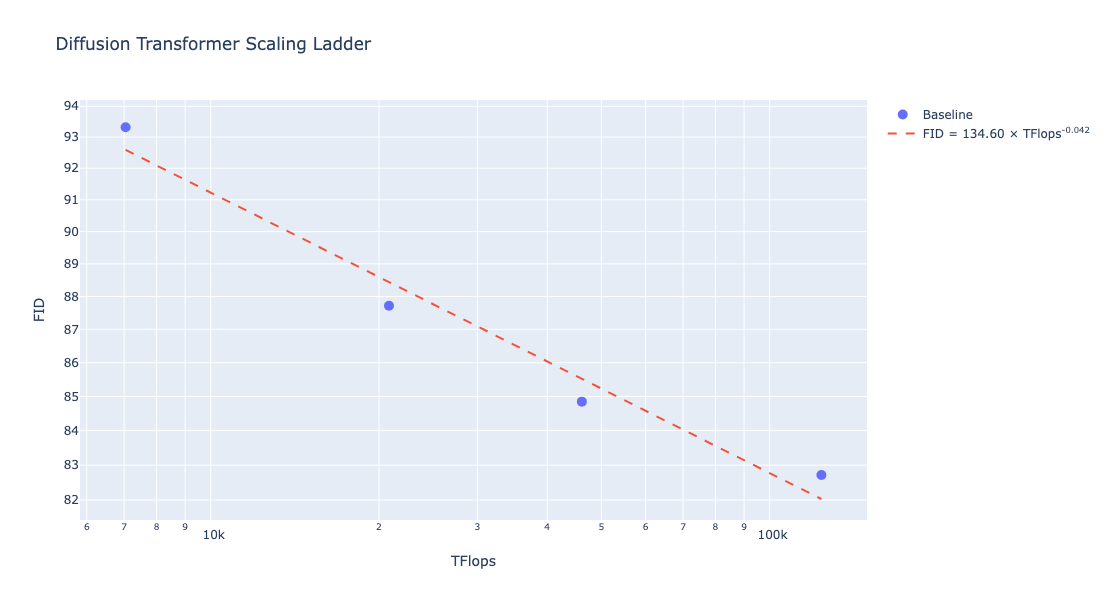

In [27]:
import numpy as np
import plotly.graph_objects as go
from sklearn.linear_model import LinearRegression

size = ['extra_small', "small", "medium", "large"]
tflops = [7041.40, 20842.84, 46138.02, 123786.66]
fid = [93.317, 87.715, 84.847, 82.716]

# Fit linear regression in log-space
log_tflops = np.log10(tflops)
log_fid = np.log10(fid)

model = LinearRegression()
model.fit(np.array(log_tflops).reshape(-1, 1), log_fid)

# Get coefficients for the power law: FID = a * TFlops^b
b = model.coef_[0]  # slope in log-space = exponent
a = 10 ** model.intercept_  # intercept in log-space

# Generate smooth line for plotting
tflops_range = np.logspace(np.log10(min(tflops)), np.log10(max(tflops)), 100)
log_tflops_range = np.log10(tflops_range)
fid_pred = 10 ** model.predict(log_tflops_range.reshape(-1, 1))

# Create figure with scatter and line of best fit
fig = go.Figure()

# Add scatter points
fig.add_trace(go.Scatter(
    x=tflops,
    y=fid,
    mode='markers',
    name='Baseline',
    marker=dict(size=10)
))

# Add line of best fit with equation in legend
equation_text = f"FID = {a:.2f} × TFlops<sup>{b:.3f}</sup>"

fig.add_trace(go.Scatter(
    x=tflops_range,
    y=fid_pred,
    mode='lines',
    name=equation_text,
    line=dict(dash='dash')
))

fig.update_yaxes(title='FID', type='log')
fig.update_xaxes(title='TFlops', type='log')
fig.update_layout(width=800, height=600, title="Diffusion Transformer Scaling Ladder")
fig.show()

The next question is to figure out which experiment to run next.

I would like to start looking into improvements on the generation end of things. Currently I do the naieve thing of generating linear steps from 0-1 but perhaps we can do better. First, let me run evaluate on the latest model (coco-only) to get a baseline.

`uv run evaluate.py +experiment=scaling_ladder_large evaluation.datasets=["coco_captions"];  while true; do it2attention start; it2attention fireworks; done`

This gave: `coco_captions: FID Score: 83.97`

First, I noticed that I have an off by one error in the generation ([0, 1-dx] rather than [dx, 1]) lets fix this and see if there is any difference.

`uv run evaluate.py +experiment=scaling_ladder_large evaluation.datasets=["coco_captions"];  while true; do it2attention start; it2attention fireworks; done`

This gave: coco_captions: `coco_captions: FID Score: 83.53`

This difference is too small to be significant (I should probably bootstrap these results to make sure)